# 🎶 Applying a Clustering Algorithm to a Spotify Tracks dataset #

**Group**: Beatriz Alves (20241747), Inês Claro (20241760), Marta Silva (20241822)

**Objective**: The aim of this project is to apply unsupervised learning to a Spotify dataset and discover meaningful insights.

**Dataset**: [Kaggle Spotify Tracks dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

-------------

## 1. Import Libraries ##

In [91]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

import streamlit as st

spotify_green = '#1DB954'

## 2. Load Data ##

In [92]:
df_spotify = pd.read_csv("dataset.csv")

df_spotify.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Exploratory Data Analysis ##

In [93]:
df_spotify.drop("Unnamed: 0", axis = 1, inplace = True) # drop the unnecessary column

print(f"Initial shape of the dataset: {df_spotify.shape}")

Initial shape of the dataset: (114000, 20)


In [94]:
df_spotify.isna().sum() # checking for missing values

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [95]:
df_spotify[df_spotify.isna().any(axis=1)] # displaying rows with missing values

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Since the missing values are all on the same row, that track will be removed.

In [96]:
df_spotify.dropna(inplace = True)

duplicates = df_spotify.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

df_spotify.drop_duplicates(inplace=True)

print(f"Shape of the dataset after duplicate removal: {df_spotify.shape}")

df_spotify.reset_index(drop=True,inplace = True)

Number of duplicate rows: 450
Shape of the dataset after duplicate removal: (113549, 20)


In [97]:
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113549 entries, 0 to 113548
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113549 non-null  int64  
 5   duration_ms       113549 non-null  int64  
 6   explicit          113549 non-null  bool   
 7   danceability      113549 non-null  float64
 8   energy            113549 non-null  float64
 9   key               113549 non-null  int64  
 10  loudness          113549 non-null  float64
 11  mode              113549 non-null  int64  
 12  speechiness       113549 non-null  float64
 13  acousticness      113549 non-null  float64
 14  instrumentalness  113549 non-null  float64
 15  liveness          113549 non-null  float64
 16  valence           11

In [98]:
audio_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness',
              'liveness', 'valence', 'tempo'] # only continuous features
df_spotify[audio_cols].describe().round(3)

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000
mean,33.324,228081.371,0.567,0.642,-8.243,0.085,0.314,0.156,0.214,0.474,122.176
std,22.284,106413.099,0.173,0.251,5.011,0.106,0.332,0.309,0.190,0.259,29.973
min,0.000,8586.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000
25%,17.000,174184.000,0.456,0.473,-9.998,0.036,0.017,0.000,0.098,0.260,99.296
50%,35.000,213000.000,0.580,0.685,-6.997,0.049,0.168,0.000,0.132,0.464,122.020
75%,50.000,261588.000,0.695,0.854,-5.001,0.084,0.596,0.049,0.273,0.683,140.074
max,100.000,5237295.000,0.985,1.000,4.532,0.965,0.996,1.000,1.000,0.995,243.372


Only continuous features were considered here since those are the numeric variables where **mean**, **std** and **percentiles** make sense.

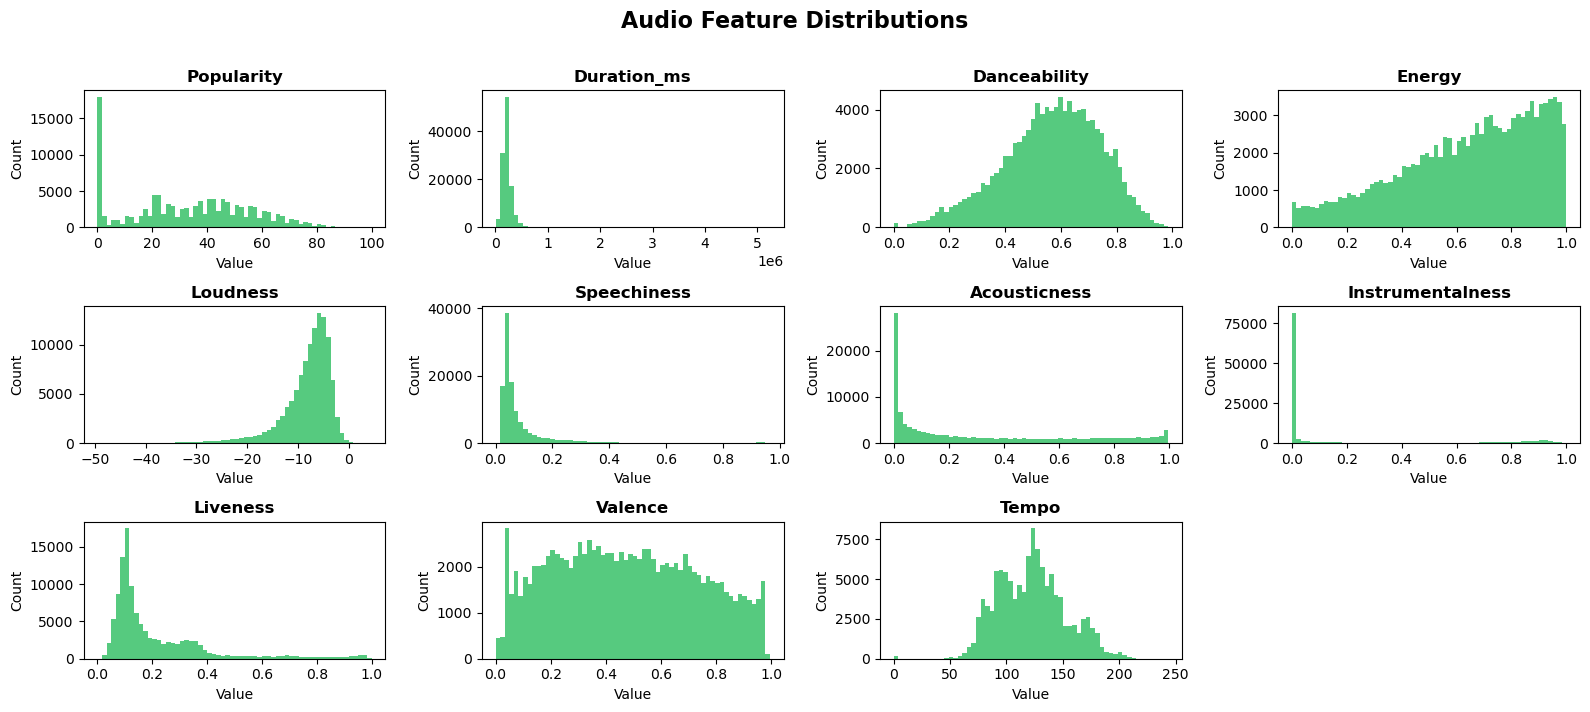

In [99]:
fig, axes = plt.subplots(3, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(audio_cols):
    axes[i].hist(df_spotify[feat], bins=60, color=spotify_green, alpha=0.75, edgecolor='none')
    axes[i].set_title(feat.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Audio Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- `speechiness`, `instrumentalness`, and `duration_ms` are heavily right-skewed → apply a log transformation
- `popularity` has a big spike at 0
- `energy`, `danceability`, and `valence` are roughly uniform


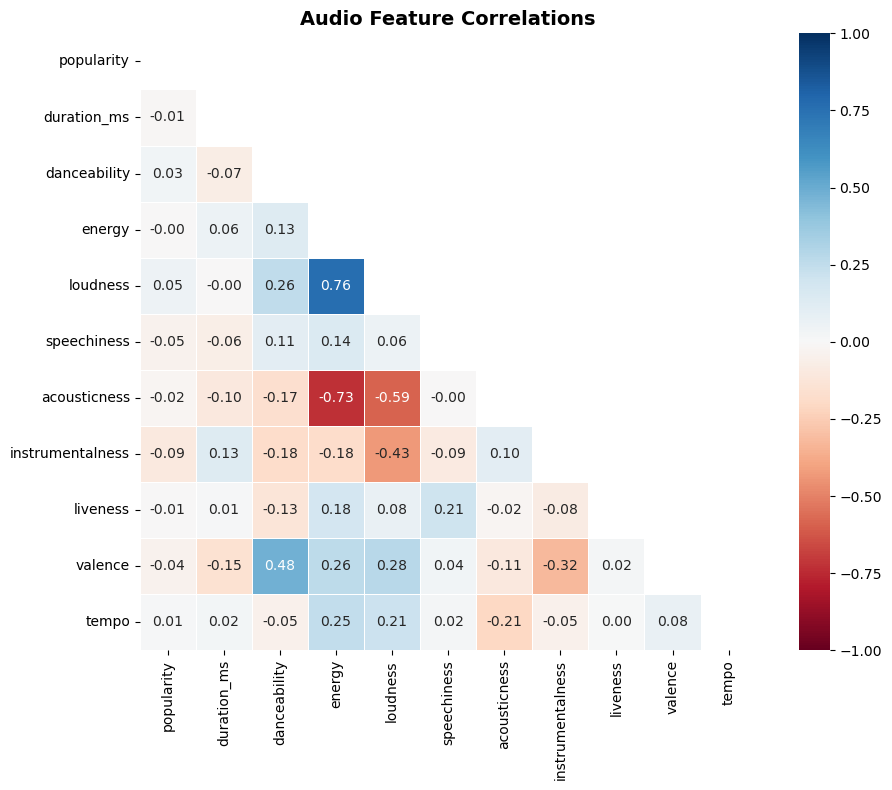

In [100]:
num_features = df_spotify[audio_cols]
corr = num_features.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Audio Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Key findings:
- `loudness` has a very strong correlation with both `energy` (0.76) and `acousticness` (-0.59)
- `acousticness` has a very strong correlation with both `energy` (-0.73) and `loudness` (-0.59)

Conclusions:
- both `loudness` and `acousticness` are not going to be considered for clustering, in order to avoid multicollinearity

## 4. Feature Engineering ##

Features used for clustering:
  popularity
  danceability
  energy
  liveness
  valence
  tempo
  log_speechiness
  log_instrumentalness
  log_duration_ms


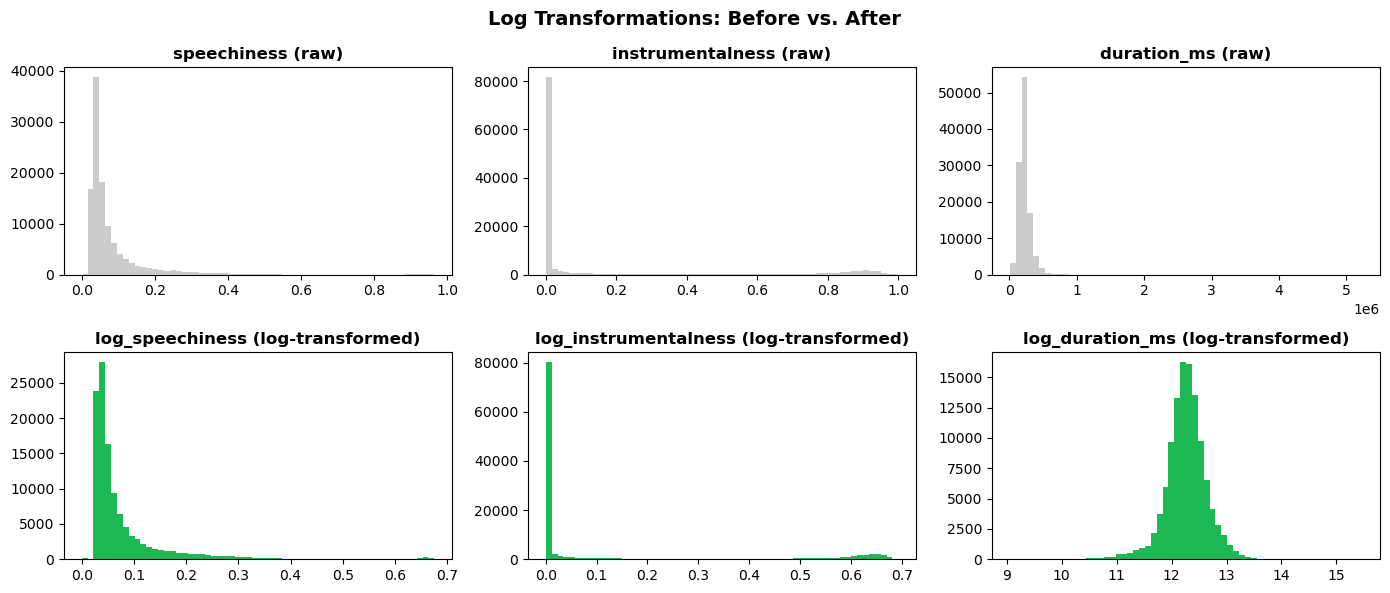

In [101]:
features = ['popularity', 'danceability', 'energy',
            'liveness', 'valence', 'tempo']

spotify_clustering = df_spotify[features].copy()

# transforming skewed features to reduce skewness and make them more suitable for clustering
spotify_clustering['log_speechiness']      = np.log1p(df_spotify['speechiness'])
spotify_clustering['log_instrumentalness'] = np.log1p(df_spotify['instrumentalness'])
spotify_clustering['log_duration_ms']      = np.log(df_spotify['duration_ms'])

print('Features used for clustering:')
for col in spotify_clustering.columns:
    print(f'  {col}')

# distribution before vs. after applying the log transformations
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, (raw, log) in enumerate([('speechiness', 'log_speechiness'),
                                  ('instrumentalness', 'log_instrumentalness'),
                                  ('duration_ms', 'log_duration_ms')]):
    axes[0, i].hist(df_spotify[raw], bins=60, color='#ccc', edgecolor='none')
    axes[0, i].set_title(f'{raw} (raw)', fontweight='bold')
    axes[1, i].hist(spotify_clustering[log], bins=60, color=spotify_green, edgecolor='none')
    axes[1, i].set_title(f'{log} (log-transformed)', fontweight='bold')

plt.suptitle('Log Transformations: Before vs. After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Data Scaling ##

Since the applied algorithms rely heavily on distances, it is essencial to scale the data before applying them.

In [102]:
scaler = RobustScaler() # using RobustScaler to reduce the influence of outliers
spotify_clustering_scaled = scaler.fit_transform(spotify_clustering)

## 6. Choose the optimal K ##

### 6.1. Elbow Method ##

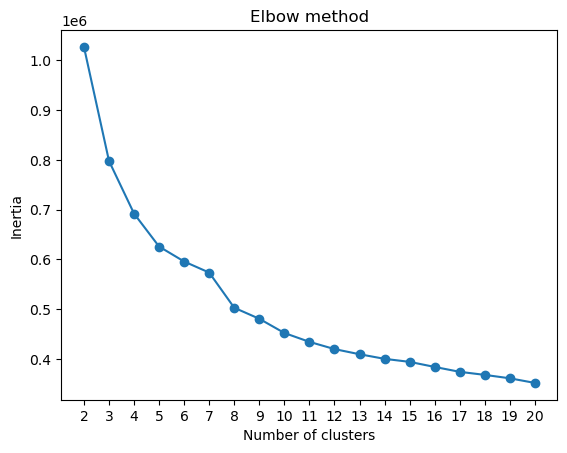

In [103]:
inertias = []

for i in range(2,21):
    kmeans = KMeans(n_clusters=i, random_state = 0)
    kmeans.fit(spotify_clustering_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(2,21), inertias, marker='o')
plt.title('Elbow method')
plt.xticks(range(2,21))
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

### 6.2. Silhouette coefficient ###

In [104]:
inertias, sil_scores = {}, {}
for k in range(2, 21):
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(spotify_clustering_scaled)
    inertias[k] = km.inertia_
    sil_scores[k] = silhouette_score(spotify_clustering_scaled, labels, sample_size=6000, random_state=0)
    print(f'  K={k:2d}  |  Inertia: {km.inertia_:,.0f}  |  Silhouette: {sil_scores[k]:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\n✅ Best K by silhouette: {best_k} (score={sil_scores[best_k]:.4f})')

  K= 2  |  Inertia: 1,026,968  |  Silhouette: 0.6913
  K= 3  |  Inertia: 797,795  |  Silhouette: 0.5186
  K= 4  |  Inertia: 692,053  |  Silhouette: 0.4925
  K= 5  |  Inertia: 625,789  |  Silhouette: 0.3439
  K= 6  |  Inertia: 595,728  |  Silhouette: 0.3199
  K= 7  |  Inertia: 573,483  |  Silhouette: 0.3013
  K= 8  |  Inertia: 502,800  |  Silhouette: 0.2161
  K= 9  |  Inertia: 480,681  |  Silhouette: 0.1995
  K=10  |  Inertia: 452,132  |  Silhouette: 0.1629
  K=11  |  Inertia: 434,294  |  Silhouette: 0.1582
  K=12  |  Inertia: 419,772  |  Silhouette: 0.1557
  K=13  |  Inertia: 409,430  |  Silhouette: 0.1536
  K=14  |  Inertia: 400,163  |  Silhouette: 0.1492
  K=15  |  Inertia: 394,088  |  Silhouette: 0.1508
  K=16  |  Inertia: 383,903  |  Silhouette: 0.1485
  K=17  |  Inertia: 374,061  |  Silhouette: 0.1469
  K=18  |  Inertia: 367,924  |  Silhouette: 0.1442
  K=19  |  Inertia: 361,075  |  Silhouette: 0.1440
  K=20  |  Inertia: 351,772  |  Silhouette: 0.1458

✅ Best K by silhouette: 2 (s

### 6.3. Comparing the two to reach the optimal K ###

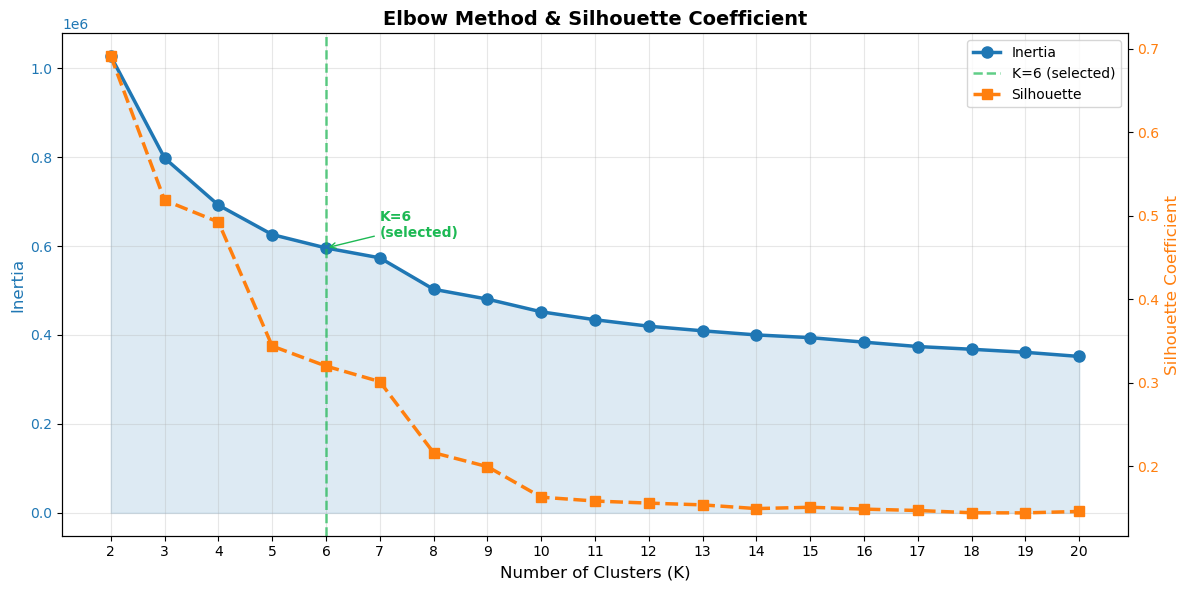

In [105]:
ks = list(range(2, 21))

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(ks, [inertias[k] for k in ks], 'o-', color='#1f77b4',
         linewidth=2.5, markersize=8, label='Inertia')
ax1.fill_between(ks, [inertias[k] for k in ks], alpha=0.15, color='#1f77b4')

ax2.plot(ks, [sil_scores[k] for k in ks], 's--', color='#ff7f0e',
         linewidth=2.5, markersize=7, label='Silhouette')

# Mark K=6
ax1.axvline(x=6, color=spotify_green, linestyle='--', linewidth=1.8, alpha=0.7, label='K=6 (selected)')
ax1.annotate('K=6\n(selected)',
             xy=(6, inertias[6]),
             xytext=(7, inertias[6] * 1.04),
             fontsize=10, color=spotify_green, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=spotify_green))

ax1.set_title('Elbow Method & Silhouette Coefficient', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12, color='#1f77b4')
ax2.set_ylabel('Silhouette Coefficient', fontsize=12, color='#ff7f0e')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')
ax1.set_xticks(ks)
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

**Conclusion**: Although the silhouette score is higher at lower K values, the inertia shows an elbow at **K = 6** or **K=7**. K = 6 also maintains a relatively high silhouette score, so we use **K = 6** as our solution.

## 7. K-means algorithm with K = 6 ##

In [107]:
names_clusters = {
    1: 'Mainstream Pop',
    0: 'Ambient / Instrumental',
    2: 'Live Spoken',
    4: 'Live Energetic',
    5: 'Ambient Live',
    3: 'Dance / Party',
}

kmeans = KMeans(n_clusters=6, random_state=0, n_init=10).fit(spotify_clustering_scaled)
spotify_clustering['cluster_kmeans'] = kmeans.predict(spotify_clustering_scaled)
#spotify_clustering['cluster_name']   = spotify_clustering['cluster_kmeans'].map(names_clusters)

sil = silhouette_score(spotify_clustering_scaled,
                       spotify_clustering['cluster_kmeans'],
                       random_state=0)
print(f'Silhouette Score (K=6): {sil:.4f}')
print(f'Inertia          (K=6): {kmeans.inertia_:,.0f}')

Silhouette Score (K=6): 0.3539
Inertia          (K=6): 559,406


Checking the clusters' centroids:

In [108]:
feat_cols = ['popularity', 'danceability', 'energy', 'liveness', 'valence',
             'tempo', 'log_speechiness', 'log_instrumentalness', 'log_duration_ms']

centroids = spotify_clustering.groupby('cluster_kmeans')[feat_cols].mean().round(3)
centroids.index.name = 'Cluster'
centroids

,popularity,danceability,energy,liveness,valence,tempo,log_speechiness,log_instrumentalness,log_duration_ms
Cluster,,,,,,,,,
0,28.626,0.500,0.536,0.179,0.295,118.619,0.062,0.611,12.306
1,34.491,0.579,0.641,0.162,0.511,122.071,0.052,0.007,12.262
2,24.319,0.568,0.687,0.674,0.436,101.559,0.616,0.003,12.118
3,31.771,0.538,0.682,0.205,0.382,124.376,0.067,0.315,12.351
4,33.083,0.652,0.718,0.205,0.546,127.307,0.231,0.007,12.145
5,35.937,0.519,0.740,0.689,0.517,124.754,0.068,0.008,12.311


**Cluster Profiles:**

- **Mainstream Pop**: High popularity and strong danceability with moderate energy. The core of commercial pop — polished, broad-appeal tracks.

- **Ambient / Instrumental**: Highly instrumental with low energy. Classical, ambient, and acoustic music with minimal or no vocals.

- **Live Spoken**: Elevated liveness and speechiness signal recordings with a strong spoken or vocal presence — live sets, comedy, or spoken-word tracks.

- **Live Energetic**: High liveness combined with high energy. Concert recordings, live rock, or any performance with crowd and intensity.

- **Ambient Live**: Moderate-to-high liveness with low energy and high instrumentalness. Quiet live sessions, acoustic sets, or ambient field recordings.

- **Dance / Party**: Maximum danceability, high valence, and strong energy. The dance floor — electronic, house, funk, and feel-good party tracks.


**NOTE**: The cluster names were given by inspecting the centroids relative to the global feature means.

Number of tracks in each cluster:

In [109]:
spotify_clustering["cluster_name"] = spotify_clustering["cluster_kmeans"].map(names_clusters)

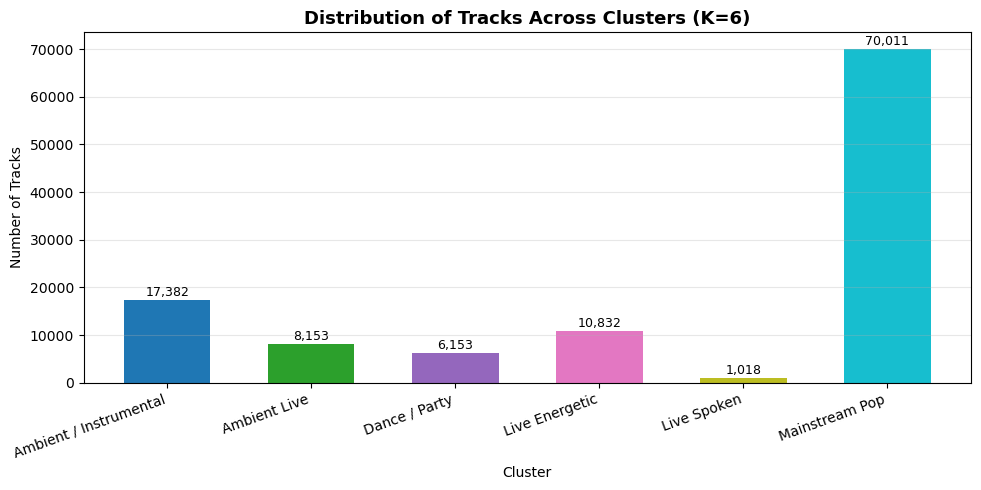

In [110]:
centroid_sizes = (
    spotify_clustering
    .groupby('cluster_name')
    .size()
    .sort_index()
)

labels = centroid_sizes.index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

bars = ax.bar(
    labels,
    centroid_sizes.values,
    color=colors,
    edgecolor='none',
    width=0.6
)

# Value labels
for bar, val in zip(bars, centroid_sizes.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title('Distribution of Tracks Across Clusters (K=6)', fontweight='bold', fontsize=13)
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Tracks')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha='right')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The **Mainstream Pop** cluster is the one with more tracks.

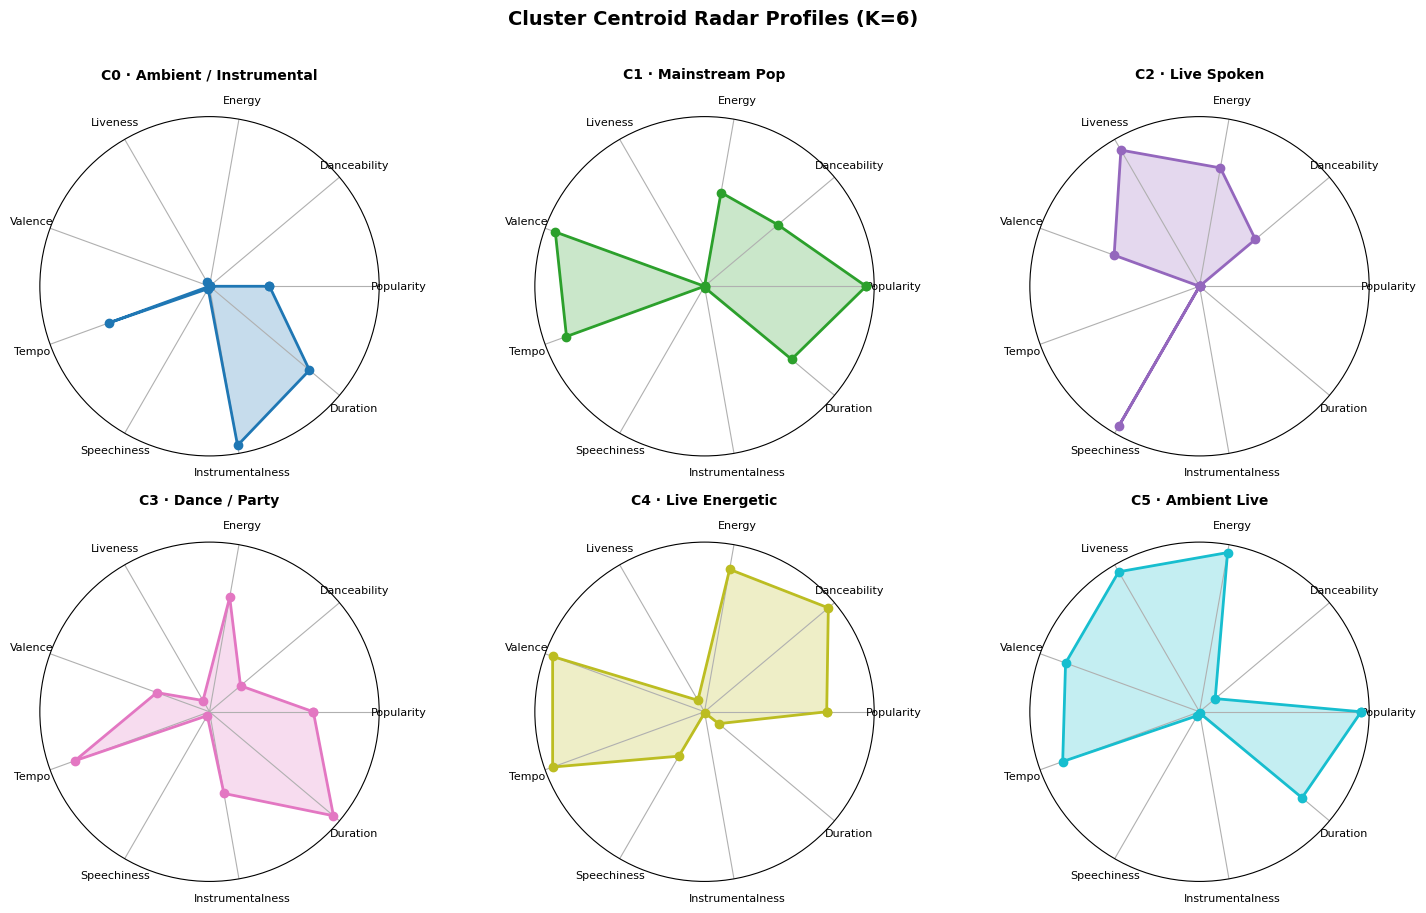

In [112]:
# ── Radar chart: cluster centroid profiles ──────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

feat_cols_radar = ['popularity', 'danceability', 'energy', 'liveness', 'valence',
                   'tempo', 'log_speechiness', 'log_instrumentalness', 'log_duration_ms']
feat_labels_radar = ['Popularity', 'Danceability', 'Energy', 'Liveness', 'Valence',
                     'Tempo', 'Speechiness', 'Instrumentalness', 'Duration']

centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
cent_df = pd.DataFrame(centroids_orig, columns=feat_cols_radar)

# Normalise to [0,1] for display
feat_min = cent_df.min()
feat_max = cent_df.max()
cent_norm = (cent_df - feat_min) / (feat_max - feat_min).replace(0, 1)

N = len(feat_labels_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors = plt.cm.tab10(np.linspace(0, 1, 6))

fig, axes = plt.subplots(2, 3, figsize=(15, 9), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx in range(6):
    ax = axes[idx]
    vals = cent_norm.iloc[idx].tolist() + [cent_norm.iloc[idx].tolist()[0]]
    color = colors[idx]

    ax.plot(angles, vals, 'o-', linewidth=2, color=color)
    ax.fill(angles, vals, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feat_labels_radar, fontsize=8)
    ax.set_yticks([])
    ax.set_title(f'C{idx} · {names_clusters[idx]}', fontsize=10,
                 fontweight='bold', pad=12)

plt.suptitle('Cluster Centroid Radar Profiles (K=6)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
